<h1 style="font-size:30px;">Global Wheat Challenge 2020: Part 1</h1>

In this notebook, we shall dive into Object Detection using one of the most popular object detection model **YOLOv8**! We would be using the **wheat-heads** dataset available from the **Global Wheat Detection Challenge**, once again a very popular competition held at Kaggle in 2020.

Once we are done fine-tuning our detection model, we shall submit our results in the competitions to see where we stand!

<img src = "https://opencv.org/wp-content/uploads/2023/06/c2_mod2_wheat_challenge_feature_image.png" width=750>

## Table of Contents


*   [1 About the Data](#1-About-the-Data)
*   [2 Why YOLOv8](#2-Why-YOLOv8?)
*   [3 Dataset Preparation for YOLOv8](#3-Dataset-Preparation-for-YOLOv8)
*   [4 Perform Training](#4-Perform-Taining)
*   [5 Predictions](#5-Predictions)
*   [6 Kaggle Submission](#6-Kaggle-Submission)
*   [7 Conclusion](#7-Conclusion)

**Let's start by installing the required dependencies.**

In [1]:
#!pip install ultralytics tensorboard

In [2]:
#!pip install numpy==1.26.1

In [1]:
import os
from shutil import copyfile, move
from dataclasses import dataclass, field
import itertools
import yaml
import csv
import cv2

from zipfile import ZipFile
import requests

import random
import math
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from ultralytics import YOLO

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1 About the Data

Our dataset is taken from the **[Global Wheat Detection Challenge](https://www.kaggle.com/competitions/global-wheat-detection/overview)** available on Kaggle.

<img src = "https://opencv.org/wp-content/uploads/2023/06/c2_mod2_wheat_head_detection.png" width=700>

The dataset consists of varied annotations of **wheat heads**, i.e, the spikes atop the plant containing grain. The dataset was curated by nine research institutes from seven countries: **the University of Tokyo**, **Institut national de recherche pour l’agriculture, l’alimentation et l’environnement, Arvalis**, **ETHZ**, **University of Saskatchewan**, **University of Queensland**, **Nanjing Agricultural University**, and **Rothamsted Research**.


The objective of the competiion was to detect wheat heads from outdoor images of wheat plants. The training data consists of `3373` images of wheat heads across varied shapes and sizes. Precisely, there are a total of `147793` annotation instances across these images.

### 1.1 Download and Extract the Dataset

In [2]:
# Download and dataset.
def download_and_unzip(url, save_path):

    print("Downloading and extracting assets...", end="")
    file = requests.get(url)
    open(save_path, "wb").write(file.content)

    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0]) # Unzip where downloaded.
            print("Done")
    except:
        print("Invalid file")

In [3]:
URL = r"https://www.dropbox.com/s/lxf5htjgmfoly7y/global-wheat-detection.zip?dl=1"

dataset_name = "global-wheat-detection"
dataset_zip_path = os.path.join(os.getcwd(), f"{dataset_name}.zip")
dataset_path = os.path.join(os.getcwd(), dataset_name)

# Download if dataset does not exists.
if not os.path.exists(dataset_path):
    download_and_unzip(URL, dataset_zip_path)
    os.remove(dataset_zip_path)

### 1.2 Dataset Format

The annotations are available in `train.csv` consisiting of 5 column fields:

- `image_id`: The unique image ID (which is the filename as well)
- `width`: The width of the image.
- `height`: the height of the image.
- `bbox`: The bounding box coordinates in $[x_{min}, \ y_{min}, \ width, \ height]$ format.
- `source`: The image source.

Let's take a look at the first 10 instances of the data.

In [4]:
ROOT_DIR = "global-wheat-detection"
data_frame = pd.read_csv(os.path.join(ROOT_DIR, "train.csv"))

print(data_frame.head(10))

    image_id  width  height                          bbox   source
0  b6ab77fd7   1024    1024    [834.0, 222.0, 56.0, 36.0]  usask_1
1  b6ab77fd7   1024    1024   [226.0, 548.0, 130.0, 58.0]  usask_1
2  b6ab77fd7   1024    1024   [377.0, 504.0, 74.0, 160.0]  usask_1
3  b6ab77fd7   1024    1024   [834.0, 95.0, 109.0, 107.0]  usask_1
4  b6ab77fd7   1024    1024   [26.0, 144.0, 124.0, 117.0]  usask_1
5  b6ab77fd7   1024    1024  [569.0, 382.0, 119.0, 111.0]  usask_1
6  b6ab77fd7   1024    1024     [52.0, 602.0, 82.0, 45.0]  usask_1
7  b6ab77fd7   1024    1024   [627.0, 302.0, 122.0, 75.0]  usask_1
8  b6ab77fd7   1024    1024    [412.0, 367.0, 68.0, 82.0]  usask_1
9  b6ab77fd7   1024    1024   [953.0, 220.0, 56.0, 103.0]  usask_1


### 1.3 Evaluation Metric

The metric sweeps over a range of IoU thresholds, at each point calculating an average precision value. The threshold values range from **`0.5`** to **`0.75`** with a step size of **`0.05`**.

At each threshold value $t$, a precision value is calculated based on the number of true positives (TP), false negatives (FN), and false positives (FP) resulting from comparing the predicted object to all ground truth objects:

$$\frac{TP(t)}{TP(t)\ + FP(t)\ + FN(t)}$$

A **true positive** is counted when a single predicted object matches a ground truth object with an **IoU** above the threshold. A **false positive** indicates a predicted object had no associated ground truth object. A **false negative** indicates a ground truth object had no associated predicted object.

The average precision of a single image is calculated as the mean of the above precision values at each IoU threshold:

$$\frac{1}{|thresholds|}\sum_{t}\frac{TP(t)}{TP(t)\ + FP(t)\ + FN(t)}$$

## 2 Why YOLOv8?

We shall try to utilize the power of **YOLOv8** for the dataset. **YOLOv8** is family of single-shot object detection models providing state-of-the-art performance in real-time.

The **YOLOv8** family of models are more accurate and faster compared to the previous versions.

Following in the footsteps of the previous version (YOLOv5 by Ultralytics), YOLOv8 models provide the following functionality:

* Object Detection,
* Instance Segmentation, and
* Image Classification.

Not only that, every task includes five different models with varying size and accuracy.

To make things simpler, we are going to use the **Ultralytics** package for training the YOLOv8 model.

### 2.1 Models Available in Ultralytics Library

Starting from the smallest and fastest **YOLOv8 Nano** (yolov8n) to the most accurate model **YOLOv8 Extra Large (yolov8x)**, there 15 models across all tasks.

Here is a list of all the YOLOv8 object detection models along with their respective mAP.

<img src="https://opencv.org/wp-content/uploads/2023/06/c2-mod2-yolov8-detection-models-table.png" width=600>

## 3 Dataset Preparation for YOLOv8

We have seen that the annotations in the dataset are of the format: `[xmin, ymin, width, height]` format. However, in order to proceed with the training we need to convert them to a format accepted by YOLO.

The bounding box annotation format across all YOLO models is:
$\mathbf{[x_{center},\ y_{center},\ width,\ height]}$, where all the coordinates are normalized in the range: `[0,1]`. We can pen down the coordinates in simple equations:

$$
\begin{align}
 x_{center-norm}  &= \frac{1}{image_{width}}\cdot\left(x_{min} + \frac{1}{2}\cdot box_{width}\right) \\
 y_{center-norm}  &= \frac{1}{image_{height}}\cdot\left(y_{min} + \frac{1}{2}\cdot box_{height}\right) \\
 box_{width-norm} &= \frac{1}{image_{width}} \cdot box_{width} \\
 box_{height-norm} &= \frac{1}{image_{height}} \cdot box_{height} \\
\end{align}
$$

The `train` sub-directory under the `global-wheat-detection` main directory contains the image files. However, we should also note that not all images files have their corresponding annotations in `train.csv`. Hence, we need to filter them out as well.

The following utility function `convert_csv2yolo` copies the image files having their matching annotations in `train.csv` and converts the box annotations in YOLO.

In [5]:
def convert_csv2yolo(df, src_path, dest_img_path, dest_label_path):

    # The dataset consists of a single class.
    CLASS_ID = 0

    grouped_data = df.groupby("image_id")

    for group, data in grouped_data:

        matches = [f for f in os.listdir(src_path) if any([f == group, f.startswith(group+".")])]
        matched_file = matches[0]

        copyfile(os.path.join(src_path, matched_file), os.path.join(dest_img_path, matched_file))

        image_width = data["width"].tolist()[0]
        image_height = data["height"].tolist()[0]

        bboxes = data["bbox"].tolist()
        txt_filename = group+".txt"

        with open(os.path.join(dest_label_path, txt_filename), "w") as f:
            for idx, box in enumerate(bboxes):
                box_data = re.split("\[|,| |\]", box)[1::2]
                box_data_np = np.array(box_data, dtype="float")

                x_center = box_data_np[0] + 0.5*box_data_np[2]
                y_center = box_data_np[1] + 0.5*box_data_np[3]

                x_c_norm = float(x_center / image_width)
                y_c_norm = float(y_center / image_height)
                box_width_norm = float(box_data_np[2] / image_width)
                box_height_norm = float(box_data_np[3] / image_height)

                if (idx+1) == len(bboxes):
                    line = f"{CLASS_ID} {x_c_norm} {y_c_norm} {box_width_norm} {box_height_norm}"
                else:
                    line = f"{CLASS_ID} {x_c_norm} {y_c_norm} {box_width_norm} {box_height_norm}\n"

                f.write(line)

    print(f"\rProcessed {len(grouped_data)} images.")
    return

Before we preapare the label `txt` files for YOLO, we shall create a new directory to store all the filtered out images first.



In [6]:
SRC_IMG_PATH = os.path.join(ROOT_DIR, "train")

DATASET_PATH      = "wheat_dataset"
TRAIN_DIR         = f"train"
TRAIN_FOLDER_IMG    = f"images"
TRAIN_FOLDER_LABELS = f"labels"

TRAIN_IMG_PATH   = os.path.join(DATASET_PATH, TRAIN_DIR, TRAIN_FOLDER_IMG)
TRAIN_LABEL_PATH = os.path.join(DATASET_PATH, TRAIN_DIR, TRAIN_FOLDER_LABELS)

os.makedirs(TRAIN_IMG_PATH, exist_ok=True)
os.makedirs(TRAIN_LABEL_PATH, exist_ok=True)

convert_csv2yolo(df=data_frame,
                 src_path=SRC_IMG_PATH,
                 dest_img_path=TRAIN_IMG_PATH,
                 dest_label_path=TRAIN_LABEL_PATH)

Processed 3373 images.


### 3.1 Dataset Partition

Since we do not have the train and validation splits at our disposal, we need to create one. We shall create the split in a `90-10` ratio.

The function `split_dataset` accepts the source and destination (validation) image and labels paths and creates the required split after shuffling the entire data. Finally, it moves the images and the label annotations into the corresponding validation paths.

Finally, the directory structure that we shall maintain for our experiments is shown in the following hierarchy.

```
wheat_dataset/
├── train
│   ├── images (3036 files)
│   └── labels (3036 files)
└── valid
    ├── images (337 files)
    └── labels (337 files)
```

In [7]:
def split_dataset(src_img_path, src_label_path, val_img_path, val_label_path, val_split=0.1):

    images_files = os.listdir(src_img_path)

    num_images = len(images_files)
    num_val_images = math.floor(val_split*num_images)

    random.seed(42)
    random_indexes = list(range(num_images))
    random.shuffle(random_indexes)

    for idx in random_indexes[:num_val_images]:

        image_filename = images_files[idx]
        label_filename = os.path.splitext(image_filename)[0]+'.txt'

        move(os.path.join(src_img_path, image_filename),os.path.join(val_img_path, image_filename))
        move(os.path.join(src_label_path, label_filename), os.path.join(val_label_path, label_filename))


    print(f"Training images: {num_images - num_val_images}, Validation Images: {num_val_images}")

In [8]:
VALID_DIR           = f"valid"
VALID_FOLDER_IMG    = f"images"
VALID_FOLDER_LABELS = f"labels"

VALID_IMG_PATH   = os.path.join(DATASET_PATH, VALID_DIR, VALID_FOLDER_IMG)
VALID_LABEL_PATH = os.path.join(DATASET_PATH, VALID_DIR, VALID_FOLDER_LABELS)


if not (os.path.exists(VALID_IMG_PATH) and os.path.exists(VALID_LABEL_PATH)):
    os.makedirs(VALID_IMG_PATH)
    os.makedirs(VALID_LABEL_PATH)
    split_dataset(TRAIN_IMG_PATH, TRAIN_LABEL_PATH, VALID_IMG_PATH, VALID_LABEL_PATH)

## 4 Perform Taining

### 4.1 Training Configuration

We will finally perform training using the YOLOv8 medium (`yolov8m`) model having the following configurations:

- epochs: `50`
- image size: `1024`
- batch size: `32`

**Note:** You need to update the above configurations depending on the compute resources available at your disposal.

In [9]:
@dataclass(frozen=True)
class TrainingConfig:
    DATASET_YAML:  str = "wheat_data.yaml"
    #MODEL:         str = "yolov8m.pt"
    MODEL:         str = "yolo26m.pt"
    EPOCHS:        int = 50
    IMAGE_SIZE:    int = 512
    BATCH_SIZE:    int = 32
    PROJECT:       str = "Global_Wheat_Challenge"
    NAME:          str = f"{MODEL.split('.')[0]}_{EPOCHS}_epochs"
    CLASSES_DICT: dict = field(default_factory = lambda:{0 : "wheat_head"})

In [10]:
train_config = TrainingConfig()

### 4.2 Dataset `yaml` file

Before we start our training, we need to create a `.yaml` containing the path to the images and labels files. Additionally, we also need to specify the class names, starting from `index=0`.

In [11]:
current_dir = os.getcwd()

data_dict = dict(
                path  = os.path.join(current_dir, DATASET_PATH),
                train = os.path.join(TRAIN_DIR, TRAIN_FOLDER_IMG),
                val   = os.path.join(VALID_DIR, VALID_FOLDER_IMG),
                names = train_config.CLASSES_DICT
               )

with open(train_config.DATASET_YAML, "w") as config_file:
    yaml.dump(data_dict, config_file)

### 4.3 Training

We shall be using Ultralytics' CLI to fine-tune our YOLOv8 medium model.

In [12]:
# Train the model.
!yolo detect train\
       model   = {train_config.MODEL}\
       data    = {train_config.DATASET_YAML}\
       epochs  = {train_config.EPOCHS}\
       imgsz   = {train_config.IMAGE_SIZE}\
       batch   = {train_config.BATCH_SIZE}\
       project = {train_config.PROJECT}\
       name    = {train_config.NAME}

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=wheat_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

In [14]:
# Train the model.
!yolo detect train\
       model   = 'yolo26l.pt'\
       data    = {train_config.DATASET_YAML}\
       epochs  = {train_config.EPOCHS}\
       imgsz   = 768 \
       batch   = {train_config.BATCH_SIZE}\
       project = 'Global_Wheat_Challenge_y26l_768' \
       name    = {train_config.NAME}

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=wheat_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

## 5 Predictions

Now that our training is complete, we shall perform visualizations on a few sample images to verify the performance of our fine-tuned model.

### 5.1 Obtain the Prediction boxes and Confidence Scores

The function `prepare_predictions` is used to obtain the prediction bboxes in `[xmin, ymin, width, height]` format and confidence scores across the test data.

In [15]:
def prepare_predictions(model, image_dir_path, image_filenames):

    preds_scores = []
    pred_boxes = []


    for image_file in image_filenames:
        img_filepath = os.path.join(image_dir_path, image_file)

        pred_results = model.predict(img_filepath, iou=0.35)[0].boxes.cpu()

        preds_scores.append(pred_results.conf.unsqueeze(dim=1).tolist())

        box_xyxy = pred_results.xyxy.int()
        box_xywh = box_xyxy.clone()
        box_xywh[:,2:] = box_xyxy[:,2:] - box_xyxy[:, :2]
        pred_boxes.append(box_xywh.tolist())


    return preds_scores, pred_boxes

Let's load our fine-tuned model weeights and provide the path to the test images.

In [17]:
# Load model weights.
weights_path = os.path.join('/home/ubuntu/wip/runs/detect/Global_Wheat_Challenge_y26l_768/yolo26m_50_epochs', "weights", "best-768.pt")
model = YOLO(weights_path)

# Provide the path to the test images.
TEST_IMG_DIR = os.path.join(ROOT_DIR, "test")
test_image_files = sorted(os.listdir(TEST_IMG_DIR))

# Prepare prediction data.
pred_confs, pred_boxes = prepare_predictions(model, TEST_IMG_DIR, test_image_files)


image 1/1 /home/ubuntu/wip/global-wheat-detection/test/2fd875eaa.jpg: 768x768 30 wheat_heads, 22.2ms
Speed: 6.7ms preprocess, 22.2ms inference, 20.1ms postprocess per image at shape (1, 3, 768, 768)

image 1/1 /home/ubuntu/wip/global-wheat-detection/test/348a992bb.jpg: 768x768 36 wheat_heads, 20.5ms
Speed: 6.1ms preprocess, 20.5ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 768)

image 1/1 /home/ubuntu/wip/global-wheat-detection/test/51b3e36ab.jpg: 768x768 26 wheat_heads, 19.5ms
Speed: 4.7ms preprocess, 19.5ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 768)

image 1/1 /home/ubuntu/wip/global-wheat-detection/test/51f1be19e.jpg: 768x768 15 wheat_heads, 22.3ms
Speed: 5.2ms preprocess, 22.3ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 768)

image 1/1 /home/ubuntu/wip/global-wheat-detection/test/53f253011.jpg: 768x768 32 wheat_heads, 22.1ms
Speed: 5.2ms preprocess, 22.1ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 768)

ima

### 5.2 Visualize Predictions

In [18]:
def draw_bbox(image, boxes, scores, class_name, color=(255, 0, 0), thickness=-1):

    overlay = image.copy()

    # Reference:
    # https://github.com/Deci-AI/super-gradients/blob/master/src/super_gradients/training/utils/visualization/detection.py

    font_size = 0.25 + 0.07 * min(overlay.shape[:2]) / 100
    font_size = max(font_size, 0.5)
    font_size = min(font_size, 0.8)
    text_offset = 7

    for box, score in zip(boxes, scores):
        xmin = box[0]
        ymin = box[1]
        xmax = box[0]+box[2]
        ymax = box[1]+box[3]

        overlay = cv2.rectangle(overlay, (xmin, ymin), (xmax, ymax), color, thickness)

        display_text = f"{class_name}: {score[0]:.2f}"

        (text_width, text_height), _ = cv2.getTextSize(display_text, cv2.FONT_HERSHEY_SIMPLEX, font_size, 2)

        cv2.rectangle(overlay,
                      (xmin, ymin),
                      (xmin + text_width + text_offset, ymin - text_height - int(15 * font_size)),
                      color, thickness=-1)


        overlay = cv2.putText(
                    overlay,
                    display_text,
                    (xmin + text_offset, ymin - int(10 * font_size)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    font_size,
                    (255, 255, 255),
                    2, lineType=cv2.LINE_AA,
                )

    return cv2.addWeighted(overlay, 0.75, image, 0.25, 0)

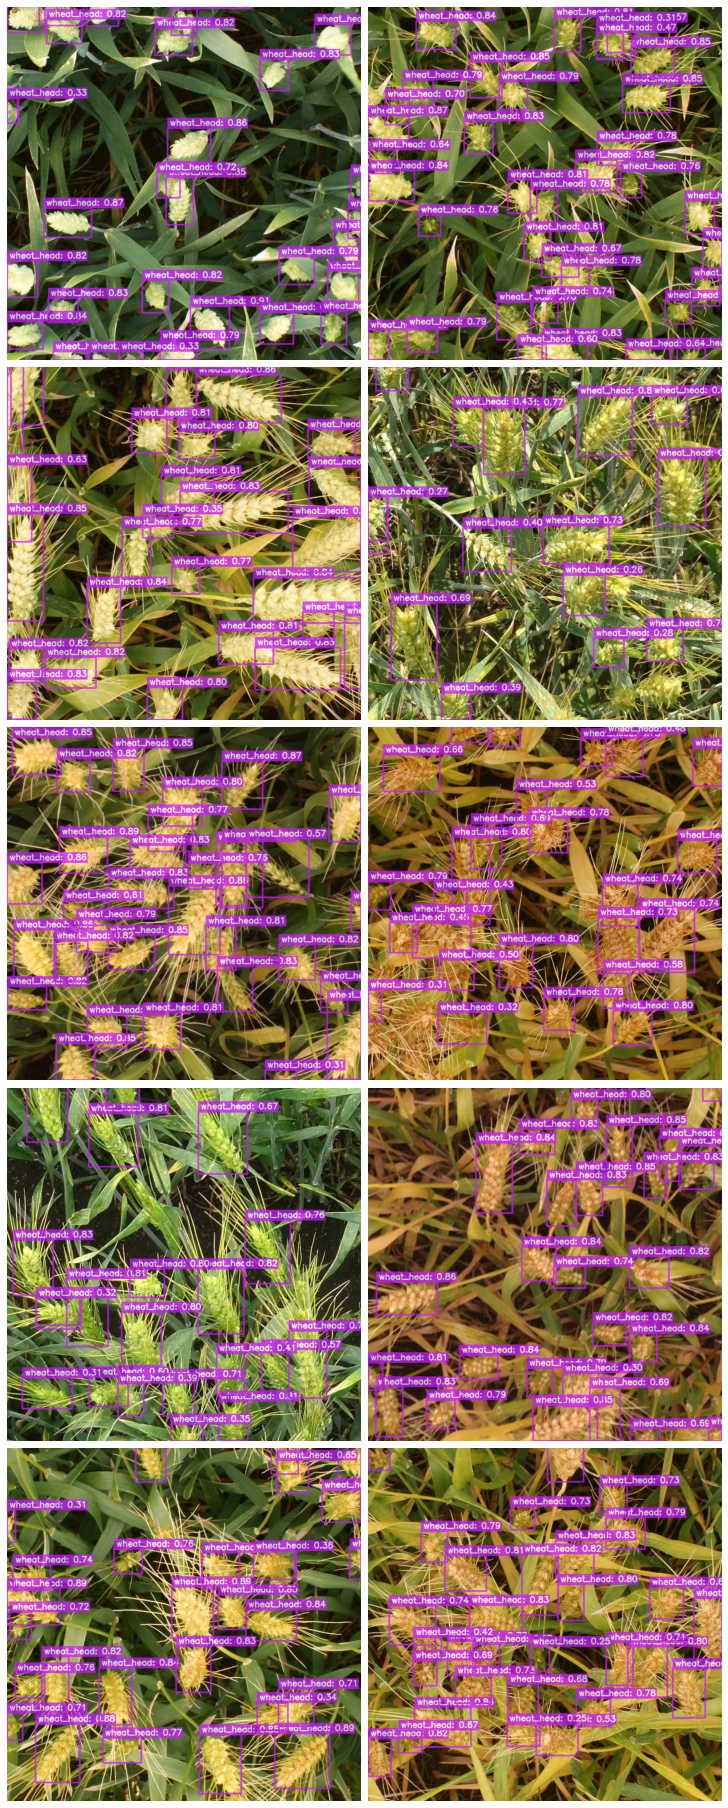

In [19]:
fig = plt.figure(figsize=(10, 25), layout="constrained")

for i,(img_file, box_data, confs) in enumerate(zip(test_image_files, pred_boxes, pred_confs)):
    filename = os.path.join(TEST_IMG_DIR, img_file)
    image = cv2.imread(filename)
    image =  draw_bbox(image, box_data, confs, class_name="wheat_head", color=(255, 26, 198), thickness=3)

    ax = plt.subplot(5, 2, i+1)
    plt.imshow(image[..., ::-1])
    plt.axis("off")


plt.show()

## 6 Kaggle Submission

The submission format requires a space delimited set of bounding boxes. For example:

`ce4833752,0.5 0 0 100 100`,

indicates that image `ce4833752` has a bounding box with a confidence of `0.5`, at `x = 0` and `y = 0`, with a `width` and `height` of `100`.

In [20]:
with open('submission.csv', 'w', newline='') as file:

    writer = csv.writer(file)
    field = ["image_id","PredictionString"]
    writer.writerow(field)

    for image_file, conf_scores, box_coords in zip(test_image_files, pred_confs, pred_boxes):

        image_id = image_file.split(".")[0]
        concat_score_boxes = [[*x, *y] for x, y in zip(conf_scores, box_coords)]
        flatten_list = list(itertools.chain(*concat_score_boxes))

        list_str = " ".join([str(item) for item in flatten_list])

        writer.writerow([image_id, list_str])

In [24]:
!ls -l {weights_path}

-rw-r--r-- 1 ubuntu ubuntu 52997797 Jun 14 17:11 /home/ubuntu/wip/runs/detect/Global_Wheat_Challenge_y26l_768/yolo26m_50_epochs/weights/best-768.pt


In [30]:
!yolo detect val model={weights_path} data=wheat_data.yaml iou=0.5 imgsz=640 name=yolov26l-640

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3465.4±598.1 MB/s, size: 219.2 KB)
val: Scanning /home/ubuntu/wip/wheat_dataset/valid/labels.cache... 337 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 337/337 58.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.4it/s 9.1s0.2s
                   all        337      14449      0.945      0.927      0.969      0.619
Speed: 0.9ms preprocess, 11.1ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /home/ubuntu/wip/runs/detect/yolov26l-640-3
💡

In [31]:
!yolo detect val model={weights_path} data=wheat_data.yaml iou=0.5 imgsz=640 half=True name=yolov26l-half-640

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3506.2±1008.4 MB/s, size: 157.4 KB)
val: Scanning /home/ubuntu/wip/wheat_dataset/valid/labels.cache... 337 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 337/337 58.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.7it/s 8.1s0.1s
                   all        337      14449      0.945      0.928      0.969      0.619
Speed: 1.0ms preprocess, 10.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/ubuntu/wip/runs/detect/yolov26l-half-6

In [32]:
!yolo detect val model={weights_path} data=wheat_data.yaml iou=0.5 imgsz=320 name=yolov26l-320

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3362.1±415.0 MB/s, size: 199.8 KB)
val: Scanning /home/ubuntu/wip/wheat_dataset/valid/labels.cache... 337 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 337/337 70.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.7it/s 8.3s0.1s
                   all        337      14449      0.929      0.879      0.933      0.539
Speed: 0.3ms preprocess, 16.5ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /home/ubuntu/wip/runs/detect/yolov26l-320-2
💡

In [33]:
!yolo detect val model={weights_path} data=wheat_data.yaml iou=0.5 imgsz=320 half=True name=yolov26l-half-320

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4331.3±988.3 MB/s, size: 220.9 KB)
val: Scanning /home/ubuntu/wip/wheat_dataset/valid/labels.cache... 337 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 337/337 52.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.9it/s 7.7s<0.2s
                   all        337      14449      0.928      0.878      0.932      0.538
Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /home/ubuntu/wip/runs/detect/yolov26l-half-32

In [34]:
!yolo detect val model={weights_path} data=wheat_data.yaml iou=0.5 imgsz=768 half=True name=yolov26l-half-768

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.7.0 CUDA:0 (NVIDIA A10, 22588MiB)
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4897.1±514.1 MB/s, size: 192.3 KB)
val: Scanning /home/ubuntu/wip/wheat_dataset/valid/labels.cache... 337 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 337/337 64.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.3it/s 9.7s0.2s
                   all        337      14449      0.943      0.926      0.969      0.616
Speed: 1.0ms preprocess, 8.3ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/ubuntu/wip/runs/detect/yolov26l-half-768

## 7 Conclusion

After submitting the results, we achieved a public and private leaderboard scores of `0.5881` and `0.6774` which is still below par.

<img src = "https://opencv.org/wp-content/uploads/2023/06/c2-mod2-kaggle-submission.png" width=900>

In the next notebook we will try to improve upon the scores by using approaches such as weighted boxes fusion, test-time augmentations (TTA), etc.